Save training data and target to files:

In [1]:
import numpy as np # for arrays
import pandas as pd # for importing csv files
from pathlib import Path
from sklearn import preprocessing #für normierung
import pickle
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import warnings # to suppress warnings
import matplotlib.pyplot as plt

scalerpath = r'C:\python\models\2025-02-24-med-bpm-phsp-chacorr-crest.pkl'
scaler = pickle.load(open(scalerpath,'rb'))
train_All = pd.read_csv(r'C:\python\gits\early-techno\matrix25-02-22-all21median.csv')

In [2]:
X = train_All.iloc[:, [3, 4, 7,-1]]
X = X.to_numpy()
X = scaler.transform(X)
y = train_All.iloc[:, [1, 2]].apply(lambda row: ' '.join(row.astype(str)), axis=1)

mapping = {
    "Germany 1985": 0,
    "Germany 1986": 1,
    "Germany 1987": 2,
    "Germany 1988": 3,
    "Germany 1989": 4,
    "Germany 1990": 5,
    "Germany 1991": 6,
    "Germany 1992": 7,
    "Germany 1993": 8,
    "Germany 1994": 9,
    "USA 1984": 10,
    "USA 1985": 11,
    "USA 1986": 12,
    "USA 1987": 13,
    "USA 1988": 14,
    "USA 1989": 15,
    "USA 1990": 16,
    "USA 1991": 17,
    "USA 1992": 18,
    "USA 1993": 19,
    "USA 1994": 20,
}

#mapping = {
#    "Germany 1985": "1985g",
#    "Germany 1986": "1986g",
#    "Germany 1987": "1987g",
#    "Germany 1988": "1988g",
#    "Germany 1989": "1989g",
#    "Germany 1990": "1990g",
#    "Germany 1991": "1991g",
#    "Germany 1992": "1992g",
#    "Germany 1993": "1993g",
#    "Germany 1994": "1994g",
#    "USA 1984": "1984u",
#    "USA 1985": "1985u",
#    "USA 1986": "1986u",
#    "USA 1987": "1987u",
#    "USA 1988": "1988u",
#    "USA 1989": "1989u",
#    "USA 1990": "1990u",
#    "USA 1991": "1991u",
#    "USA 1992": "1992u",
#    "USA 1993": "1993u",
#    "USA 1994": "1994u",
#}

# Using a list comprehension to map the labels to numbers
y = [mapping.get(item) for item in y]
labels = ['1985g','1986g','1987g','1988g','1989g','1990g','1991g','1992g','1993g','1994g','1984u','1985u','1986u','1987u','1988u','1989u','1990u','1991u','1992u','1993u','1994u']

## Step 5: Train-Test-Split

## Step 6: Train and validate a classifier

### Random Forest

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split# splits the feature matrix into training data of test_size a
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [19]:
# Example: Assume you have features in X and labels in y
# X = your_feature_dataframe
# y = your_label_series
warnings.filterwarnings("ignore")

# Initialize lists to store metrics
train_accuracies = []
test_accuracies = []
confusion_matrices = []
precision = []
recall = []
f1 = []

for i in range(100):
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=i,stratify=y)

    # Create and train the Random Forest classifier
    rf = RandomForestClassifier(random_state=i)
    rf.fit(X_train, y_train)

    # Make predictions on the test set
    rf_predict = rf.predict(X_test)

    # Calculate and store metrics
    train_accuracy = rf.score(X_train, y_train)
    test_accuracy = rf.score(X_test, y_test)
    cmrf = confusion_matrix(y_test, rf_predict)
    #cmrf = cmrf.astype('float') / cmrf.sum(axis=1)[:, np.newaxis] * 100  # Normalize to percentages
    cmdrf = ConfusionMatrixDisplay(cmrf,display_labels=labels)#
    #cmdrf.plot()
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)
    confusion_matrices.append(cmrf)
    precision.append(precision_score(y_test, rf_predict, average='weighted'))  # Adjust for binary/multi-class
    recall.append(recall_score(y_test, rf_predict, average='weighted'))         # Adjust for binary/multi-class
    f1.append(f1_score(y_test, rf_predict, average='weighted'))

# After the loop, you can average the metrics or analyze them further
plt.figure(figsize=(10, 8))
average_train_accuracy = np.mean(train_accuracies)
average_test_accuracy = np.mean(test_accuracies)
average_precision = np.mean(precision)
average_recall = np.mean(recall)
average_f1 = np.mean(f1)

print(f'Average Train Accuracy: {average_train_accuracy:.3f}')
print(f'Average Test Accuracy: {average_test_accuracy:.3f}')
print(f'Average Precision: {average_precision:.3f}')
print(f'Average Recall: {average_recall:.3f}')
print(f'Average f1: {average_f1:.3f}')

# Ensure all confusion matrices have the same shape before averaging
shapes = [cm.shape for cm in confusion_matrices]
unique_shapes = set(shapes)
print(f'Unique shapes in confusion matrices: {unique_shapes}')

average_confusion_matrix = np.mean(confusion_matrices, axis=0)
average_confusion_matrix = average_confusion_matrix.astype('float') / average_confusion_matrix.sum(axis=1)[:, np.newaxis] * 100
cmdrf = ConfusionMatrixDisplay(average_confusion_matrix, display_labels=labels)  # Ensure labels match your classes
#cmdrf.plot()
plt.show()

Average Train Accuracy: 1.000
Average Test Accuracy: 0.268
Average Precision: 0.248
Average Recall: 0.268
Average f1: 0.255
Unique shapes in confusion matrices: {(21, 21)}


<Figure size 1000x800 with 0 Axes>

<Figure size 3200x2800 with 0 Axes>

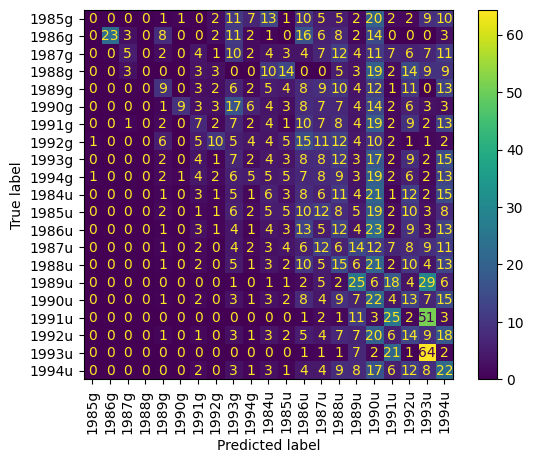

In [17]:
#%matplotlib inline
plt.figure(figsize=(16, 14),dpi=200)  # You can adjust these numbers to make it larger or smaller
cmdrf = ConfusionMatrixDisplay(average_confusion_matrix, display_labels=labels)
cmdrf.plot(values_format='.0f')  # Use values_format to control how the numbers are formatted
#plt.title('Average Confusion Matrix')  # Optional: Add a title
plt.xticks(rotation=90)
plt.show()

### Support Vector Machine

In [7]:
from sklearn import svm

warnings.filterwarnings("ignore")

# Initialize lists to store metrics
train_accuracies = []
test_accuracies = []
confusion_matrices = []
precision = []
recall = []
f1 = []

for i in range(100):
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=i,stratify=y)

    # Create and train the Random Forest classifier
    clf=svm.SVC(random_state=i)
    clf.fit(X_train, y_train)

    # Make predictions on the test set
    clf_predict = clf.predict(X_test)

    # Calculate and store metrics
    train_accuracy = clf.score(X_train, y_train)
    test_accuracy = clf.score(X_test, y_test)
    cmclf = confusion_matrix(y_test, clf_predict)
    cmdclf = ConfusionMatrixDisplay(cmclf,display_labels=labels)#
    #cmdrf.plot()
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)
    confusion_matrices.append(cmclf)
    precision.append(precision_score(y_test, clf_predict, average='weighted'))  # Adjust for binary/multi-class
    recall.append(recall_score(y_test, clf_predict, average='weighted'))         # Adjust for binary/multi-class
    f1.append(f1_score(y_test, clf_predict, average='weighted'))

# After the loop, you can average the metrics or analyze them further
plt.figure(figsize=(10, 8))
average_train_accuracy = np.mean(train_accuracies)
average_test_accuracy = np.mean(test_accuracies)
average_precision = np.mean(precision)
average_recall = np.mean(recall)
average_f1 = np.mean(f1)

print(f'Average Train Accuracy: {average_train_accuracy:.3f}')
print(f'Average Test Accuracy: {average_test_accuracy:.3f}')
print(f'Average Precision: {average_precision:.3f}')
print(f'Average Recall: {average_recall:.3f}')
print(f'Average f1: {average_f1:.3f}')

# Ensure all confusion matrices have the same shape before averaging
shapes = [cm.shape for cm in confusion_matrices]
unique_shapes = set(shapes)
print(f'Unique shapes in confusion matrices: {unique_shapes}')

average_confusion_matrix = np.mean(confusion_matrices, axis=0)
average_confusion_matrix = average_confusion_matrix.astype('float') / average_confusion_matrix.sum(axis=1)[:, np.newaxis] * 100
cmdclf = ConfusionMatrixDisplay(average_confusion_matrix, display_labels=labels)  # Ensure labels match your classes
#cmdrf.plot()
plt.show()


Average Train Accuracy: 0.309
Average Test Accuracy: 0.286
Average Precision: 0.237
Average Recall: 0.286
Average f1: 0.214
Unique shapes in confusion matrices: {(21, 21)}


<Figure size 1000x800 with 0 Axes>

<Figure size 3200x2800 with 0 Axes>

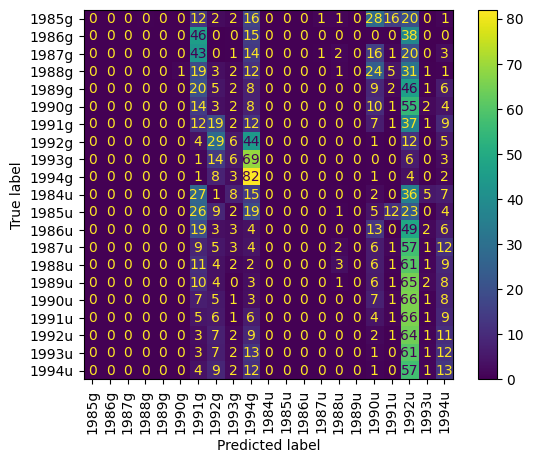

In [8]:
#%matplotlib inline
plt.figure(figsize=(16, 14),dpi=200)  # You can adjust these numbers to make it larger or smaller
cmdclf = ConfusionMatrixDisplay(average_confusion_matrix, display_labels=labels)
cmdclf.plot(values_format='.0f')  # Use values_format to control how the numbers are formatted
#plt.title('Average Confusion Matrix')  # Optional: Add a title
plt.xticks(rotation=90)
plt.show()

In [ ]:
clf_predict = clf.predict(X_test)
cmclf = confusion_matrix(y_test, clf_predict)
cmdclf = ConfusionMatrixDisplay(cmclf, display_labels=labels)
cmdclf.plot()
print(classification_report(y_test, clf_predict))
print(f'Train Accuracy: {clf.score(X_train, y_train):.3f}')
print(f'Test Accuracy: {clf.score(X_test, y_test):.3f}')

### Multi Layer Perceptron Neural Network

In [ ]:
from sklearn.neural_network import MLPClassifier

mlpc = MLPClassifier(hidden_layer_sizes=(11,11,11), max_iter=500)
mlpc.fit(X_train,y_train)
pred_mlpc = mlpc.predict(X_test)
print(f'Train Accuracy: {mlpc.score(X_train, y_train):.3f}')
print(f'Test Accuracy: {mlpc.score(X_test, y_test):.3f}')

In [12]:
from sklearn.neural_network import MLPClassifier

warnings.filterwarnings("ignore")

# Initialize lists to store metrics
train_accuracies = []
test_accuracies = []
confusion_matrices = []
precision = []
recall = []
f1 = []

for i in range(100):
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=i,stratify=y)

    # Create and train the Random Forest classifier
    mlp=MLPClassifier(hidden_layer_sizes=(11,11,11), max_iter=500, random_state=i)
    mlp.fit(X_train, y_train)

    # Make predictions on the test set
    mlp_predict = mlp.predict(X_test)

    # Calculate and store metrics
    train_accuracy = mlp.score(X_train, y_train)
    test_accuracy = mlp.score(X_test, y_test)
    cmmlp = confusion_matrix(y_test, mlp_predict)
    cmdmlp = ConfusionMatrixDisplay(cmmlp,display_labels=labels)#
    #cmdrf.plot()
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)
    confusion_matrices.append(cmmlp)
    precision.append(precision_score(y_test, mlp_predict, average='weighted'))  # Adjust for binary/multi-class
    recall.append(recall_score(y_test, mlp_predict, average='weighted'))         # Adjust for binary/multi-class
    f1.append(f1_score(y_test, mlp_predict, average='weighted'))

# After the loop, you can average the metrics or analyze them further
plt.figure(figsize=(10, 8))
average_train_accuracy = np.mean(train_accuracies)
average_test_accuracy = np.mean(test_accuracies)
average_precision = np.mean(precision)
average_recall = np.mean(recall)
average_f1 = np.mean(f1)

print(f'Average Train Accuracy: {average_train_accuracy:.3f}')
print(f'Average Test Accuracy: {average_test_accuracy:.3f}')
print(f'Average Precision: {average_precision:.3f}')
print(f'Average Recall: {average_recall:.3f}')
print(f'Average f1: {average_f1:.3f}')

# Ensure all confusion matrices have the same shape before averaging
shapes = [cm.shape for cm in confusion_matrices]
unique_shapes = set(shapes)
print(f'Unique shapes in confusion matrices: {unique_shapes}')

average_confusion_matrix = np.mean(confusion_matrices, axis=0)
average_confusion_matrix = average_confusion_matrix.astype('float') / average_confusion_matrix.sum(axis=1)[:, np.newaxis] * 100
cmdmlp = ConfusionMatrixDisplay(average_confusion_matrix, display_labels=labels)  # Ensure labels match your classes
#cmdrf.plot()
plt.show()

Average Train Accuracy: 0.304
Average Test Accuracy: 0.291
Average Precision: 0.238
Average Recall: 0.291
Average f1: 0.236
Unique shapes in confusion matrices: {(21, 21)}


<Figure size 1000x800 with 0 Axes>

<Figure size 3200x2800 with 0 Axes>

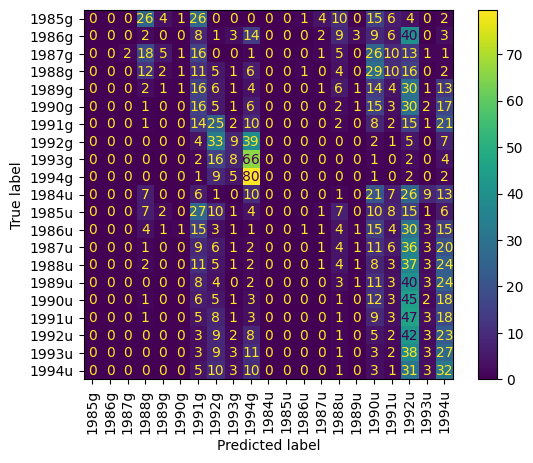

In [13]:
#%matplotlib inline
plt.figure(figsize=(16, 14),dpi=200)  # You can adjust these numbers to make it larger or smaller
cmdmlp = ConfusionMatrixDisplay(average_confusion_matrix, display_labels=labels)
cmdmlp.plot(values_format='.0f')  # Use values_format to control how the numbers are formatted
#plt.title('Average Confusion Matrix')  # Optional: Add a title
plt.xticks(rotation=90)
plt.show()